In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression,LogisticRegression

x=np.array([[1],[2],[3],[4],[5],[6],[7],[8]])
y_reg=np.array([30,40,45,55,65,75,80,90])
y_class=np.array([0,0,0,0,1,1,1,1])
lin=LinearRegression()
lin.fit(x,y_reg)
print('Regression output:',lin.predict([[0.73]]))



Regression output: [27.68571429]


In [ ]:
X=np.array([[1],[2],[3],[4],[5],[6],[7],[8]])
y_reg=np.array([30,40,45,55,65,75,80,90])
y_class=np.array([0,0,0,0,1,1,1,1])
log=LogisticRegression()
log.fit(X,y_class)
print('classification output:',log.predict([[0.73]]))
print('Probability output:',log.predict_proba([[0.73]]))



classification output: [0]
Probability output: [[0.98799263 0.01200737]]


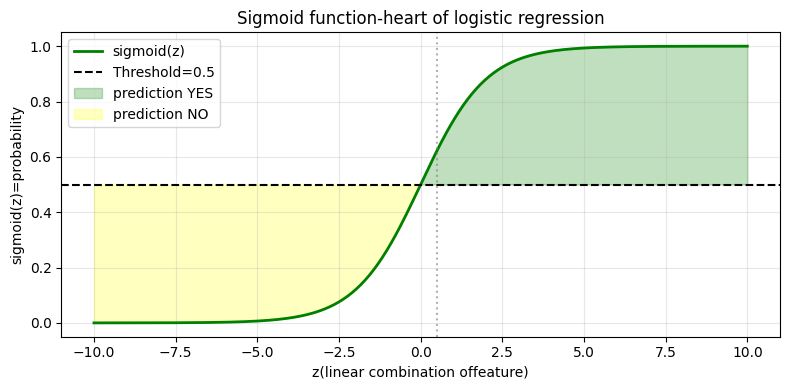

sigmoid(0)=0.5000
sigmoid(10)= 0.9933
sigmoid(-10)=0.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(z):
  return 1/(1+np.exp(-z))
z=np.linspace(-10,10,300)
prob=sigmoid(z)
plt.figure(figsize=(8,4))
plt.plot(z,prob,color='green',linewidth=2,label='sigmoid(z)')
plt.axhline(y=0.5,color='black',linestyle='--',label='Threshold=0.5')
plt.axvline(x=0.5,color='gray',linestyle=':',alpha=0.6)
plt.fill_between(z,prob,0.5,where=(prob>0.5),alpha=0.25,color='green',label='prediction YES')
plt.fill_between(z,prob,0.5,where=(prob<0.5),alpha=0.25,color='yellow',label='prediction NO')
plt.xlabel('z(linear combination offeature)')
plt.ylabel('sigmoid(z)=probability')
plt.title('Sigmoid function-heart of logistic regression')
plt.legend();plt.grid(alpha=0.3);plt.tight_layout()
plt.show()
print(f'sigmoid(0)={sigmoid(0):.4f}')
print(f'sigmoid(10)= {sigmoid(5):.4f}')
print(f'sigmoid(-10)={sigmoid(-10):.4f}')




In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.model_selection import train_test_split

x,y=make_classification(n_samples=500,n_features=5,weights=[0.7,0.3],random_state=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1548264)
model = LogisticRegression()
model.fit(x_train,y_train)
probs=model.predict_proba(x_test)[:,1]
print(f'{'Threshold':>10}{'precision':>10}{'recall':>8}{'F1 score':>6}')
print('-'*45)
for threshold in [0.2,0.3,0.4,0.5,0.6,0.7,0.8]:
  preds=(probs>=threshold).astype(int)
  precision=precision_score(y_test,preds,zero_division=0)
  recall=recall_score(y_test,preds)
  f1=f1_score(y_test,preds,zero_division=0)
  print(f'{threshold:>10.1f}{precision:>10.3f}{recall:>8.3f}{f1:>6.3f}')
#y_pred=model.predict(x_test)
#print('Precision:',precision_score(y_test,y_pred))
#print('Recall:',recall_score(y_test,y_pred))

 Threshold precision  recallF1 score
---------------------------------------------
       0.2     0.825   0.940 0.879
       0.3     0.865   0.900 0.882
       0.4     0.896   0.860 0.878
       0.5     0.956   0.860 0.905
       0.6     0.955   0.840 0.894
       0.7     0.955   0.840 0.894
       0.8     0.975   0.780 0.867


TP:5,TN:4,FP:3,FN:3
Accuracy:(TP+TN)/Total=(5+4)/15=60.00%
precision=TP/(TP+FP)=5/(8)=62.50%
Recall=TP/(TP+FN)=5/(8)=62.50%
Confusion matrix:
 [[4 3]
 [3 5]]


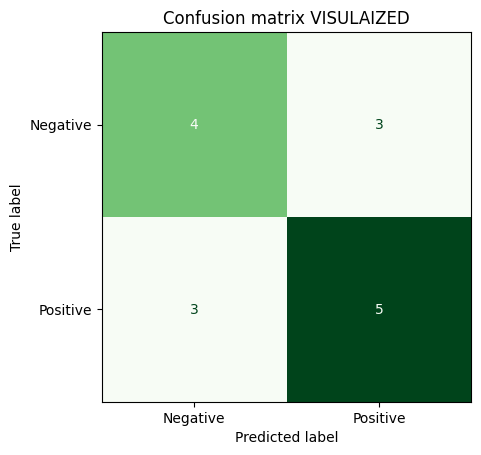

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_true=[1,1,1,1,1,  0,0,0,0,0, 1,0,1,0,1]
y_pred=[1,1,1,0,0,  0,0,0,1,1, 1,0,0,1,1]
y_true=np.array(y_true)
y_pred=np.array(y_pred)
TP=((y_pred==1)&(y_true==1)).sum()
TN=((y_pred==0)&(y_true==0)).sum()
FP=((y_pred==1)&(y_true==0)).sum()
FN=((y_pred==0)&(y_true==1)).sum()
print(f'TP:{TP},TN:{TN},FP:{FP},FN:{FN}')
print(f'Accuracy:(TP+TN)/Total=({TP}+{TN})/{len(y_true)}={(TP+TN)/len(y_true):.2%}')
print(f'precision=TP/(TP+FP)={TP}/({TP+FP})={TP/(TP+FP):.2%}')
print(f'Recall=TP/(TP+FN)={TP}/({TP+FN})={TP/(TP+FN):.2%}')
#method 2
cm=confusion_matrix(y_true,y_pred)
print('Confusion matrix:\n',cm)
disp=ConfusionMatrixDisplay(cm,display_labels=['Negative','Positive'])
disp.plot(cmap='Greens',colorbar=False)
plt.title('Confusion matrix VISULAIZED')
plt.show()

In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,f1_score,accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
x_bal,y_bal=make_classification(n_samples=1000,weights=[0.5,0.5],random_state=1)
x_imb,y_imb=make_classification(n_samples=1000,weights=[0.99,0.1],random_state=1)
def evaluate(x,y, label):
  x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1548264)
  model=LogisticRegression(max_iter=1000).fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred,zero_division=0)
  print(f'\n==={label}===')
  print(f'Accuracy:{acc:.2%}←{'MISLEADING'if f1 <0.5 else 'OK'}')
  print(f'Accuracy:{acc:.2%}<-{'MISLEADING'if f1 <0.5 else 'OK'}')
  print(f'F1 score:{f1:.2%}← Real Performance')
  print(f'F1 score:{f1:.2%}<- Real Performance')
  print(classification_report(y_test,y_pred,zero_division=0))
evaluate(x_bal,y_bal,'Balanced dataset')
evaluate(x_imb,y_imb,'Imbalanced dataset')

x_train,x_test,y_train.y_test=train_test_split(x_imb,y_imb,test_size=0.2,random_state=15)
model_fixed=LogisticRegression(max_iter=10000).fit(x_train,y_train)
y_pred_fixed=model_fixed.predict(x_test)
print('\n=== After class_weight=balanced===')
print(classification_report(y_test,y_pred,zero_division=0))


===Balanced dataset===
Accuracy:87.67%←OK
Accuracy:87.67%<-OK
F1 score:87.29%← Real Performance
F1 score:87.29%<- Real Performance
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       155
           1       0.87      0.88      0.87       145

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300


===Imbalanced dataset===
Accuracy:92.67%←MISLEADING
Accuracy:92.67%<-MISLEADING
F1 score:8.33%← Real Performance
F1 score:8.33%<- Real Performance
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       278
           1       0.50      0.05      0.08        22

    accuracy                           0.93       300
   macro avg       0.71      0.52      0.52       300
weighted avg       0.90      0.93      0.90       300



ValueError: too many values to unpack (expected 3)

In [ ]:
# ■■ Precision, Recall, F1 — Balanced vs Imbalanced ■■
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
# ■■ Balanced dataset (50/50) ■■
X_bal, y_bal = make_classification(n_samples=1000, weights=[0.5, 0.5], random_state=1)
# ■■ Imbalanced dataset (99/1) ■■
X_imb, y_imb = make_classification(n_samples=1000, weights=[0.99, 0.01], random_state=1)
def evaluate(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
    model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f'\n=== {label} ===')
    print(f'Accuracy : {acc:.2%} ← {'MISLEADING!' if f1 < 0.5 else 'OK'}')
    print(f'F1 Score : {f1:.2%} ← Real performance')
    print(classification_report(y_test, y_pred, zero_division=0))
evaluate(X_bal, y_bal,'balanced data')
evaluate(X_imb, y_imb,'imbalanced data')
# ■■ Fix imbalanced: use class_weight='balanced' ■■
X_train, X_test, y_train, y_test = train_test_split(X_imb, y_imb, test_size=0.2, random_state=42)

model_fixed = LogisticRegression(class_weight='balanced', max_iter=1000)

model_fixed.fit(X_train, y_train)

y_pred_fixed = model_fixed.predict(X_test)

print('\n=== After class_weight=balanced ===')
print(classification_report(y_test, y_pred_fixed, zero_division=0))



=== balanced data ===
Accuracy : 80.50% ← OK
F1 Score : 80.00% ← Real performance
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       106
           1       0.77      0.83      0.80        94

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.80       200
weighted avg       0.81      0.81      0.81       200


=== imbalanced data ===
Accuracy : 97.50% ← MISLEADING!
F1 Score : 0.00% ← Real performance
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.97       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.97      0.97       200


=== After class_weight=balanced ===
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       196
           1       0.04 

In [ ]:
print(f'Logistic Regression AUC: {auc_lr:.4f}')
print(f'Decision Tree AUC: {auc_dt:.4f}')
print('Higher AUC = better model at separating classes')

Logistic Regression AUC: 0.9833
Decision Tree AUC: 0.9647
Higher AUC = better model at separating classes


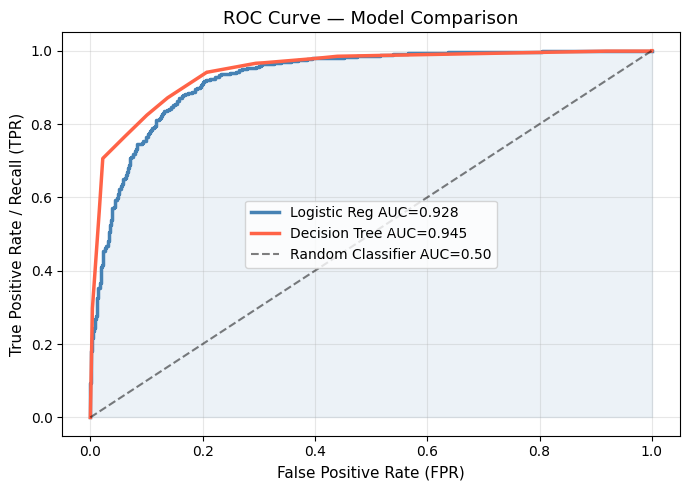

In [ ]:
# ■■ ROC Curve: Compare Two Models ■■
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
X, y = make_classification(n_samples=8000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Model 1: Logistic Regression
lr = LogisticRegression().fit(X_train, y_train)
prob_lr = lr.predict_proba(X_test)[:, 1]
# Model 2: Decision Tree (for comparison)
dt = DecisionTreeClassifier(max_depth=4).fit(X_train, y_train)
prob_dt = dt.predict_proba(X_test)[:, 1]
# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, prob_dt)
auc_lr = roc_auc_score(y_test, prob_lr)
auc_dt = roc_auc_score(y_test, prob_dt)
# Plot both on same chart
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, lw=2.5, color='steelblue', label=f'Logistic Reg AUC={auc_lr:.3f}')
plt.plot(fpr_dt, tpr_dt, lw=2.5, color='tomato', label=f'Decision Tree AUC={auc_dt:.3f}')
plt.plot([0,1],[0,1], 'k--', alpha=0.5, label='Random Classifier AUC=0.50')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate / Recall (TPR)', fontsize=11)
plt.title('ROC Curve — Model Comparison', fontsize=13)
plt.legend(fontsize=10); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0.33   11.76     0.48  
min                        0.08 

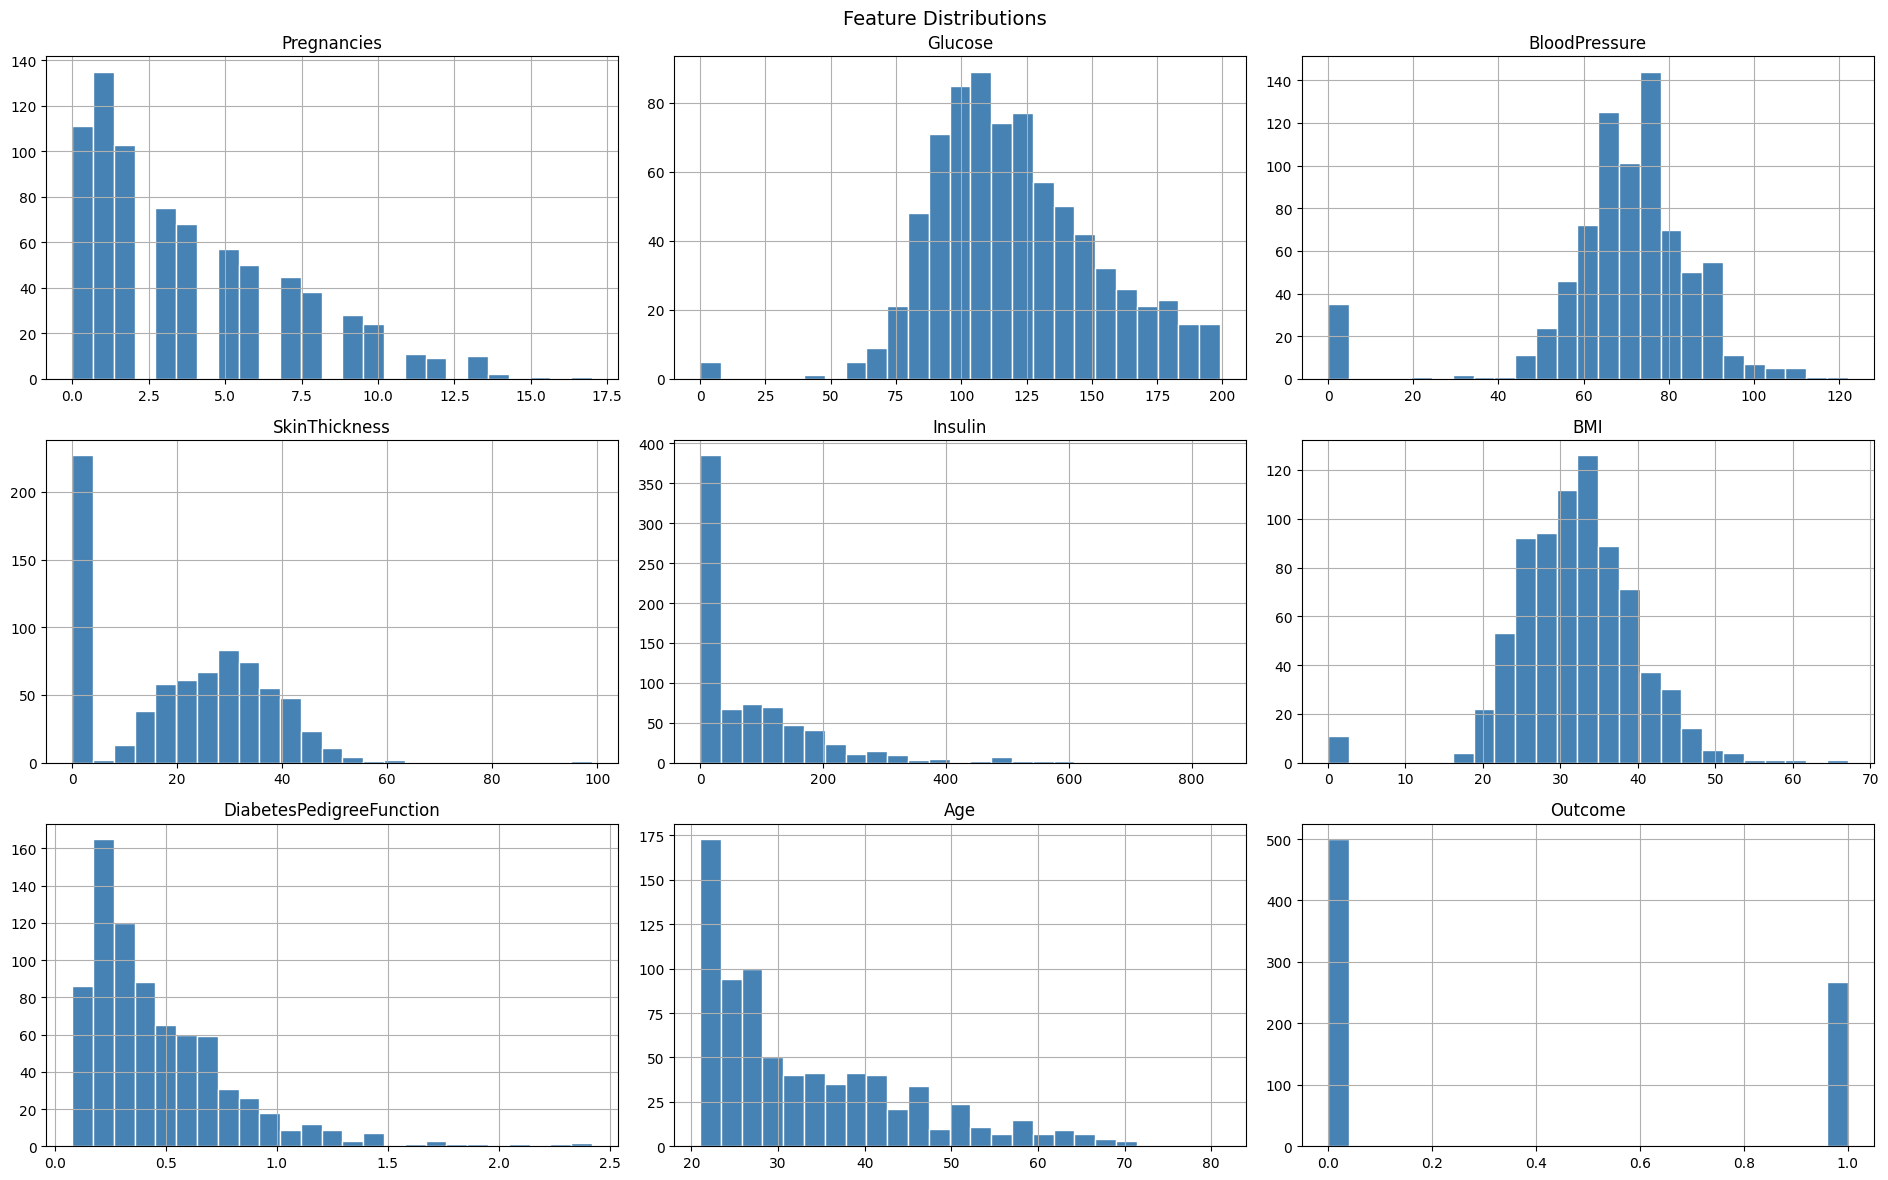

In [ ]:
# ■■ Load and Explore ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
ConfusionMatrixDisplay, roc_auc_score, roc_curve)

# Download the dataset if not already present
!test -f diabetes.csv || wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

df = pd.read_csv('diabetes.csv') # https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
print(df.shape) # (768, 9)
print(df['Outcome'].value_counts()) # 500 healthy, 268 diabetic
print(df.describe().round(2)) # stats: mean/std/min/max
# Distribution of each feature vs outcome
df.hist(bins=25, figsize=(19,12), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14); plt.tight_layout(); plt.show()

In [ ]:
# ■■ Handle Missing Values ■■
# Glucose, BMI, etc. cannot be 0 — these are missing values disguised as zeros
fix_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in fix_cols:
    n = (df[col] == 0).sum()
    df[col] = df[col].replace(0, df[col].median())
    print(f'{col:25s}: {n} zeros → replaced with median {df[col].median():.1f}')

Glucose                  : 5 zeros → replaced with median 117.0
BloodPressure            : 35 zeros → replaced with median 72.0
SkinThickness            : 227 zeros → replaced with median 23.0
Insulin                  : 374 zeros → replaced with median 31.2
BMI                      : 11 zeros → replaced with median 32.0


In [ ]:
# ■■ Split, Scale, Train ■■
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y # stratify keeps class ratio
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # fit on train, transform train
X_test = scaler.transform(X_test) # only transform test (no leakage!)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
# Print learned coefficient for each feature
for name, coef in zip(X.columns, model.coef_[0]):
    print(f'{name:30s}: {coef:+.3f}') # positive → increases diabetes risk

Pregnancies                   : +0.376
Glucose                       : +1.209
BloodPressure                 : -0.054
SkinThickness                 : +0.029
Insulin                       : -0.133
BMI                           : +0.701
DiabetesPedigreeFunction      : +0.245
Age                           : +0.138


              precision    recall  f1-score   support

     Healthy       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



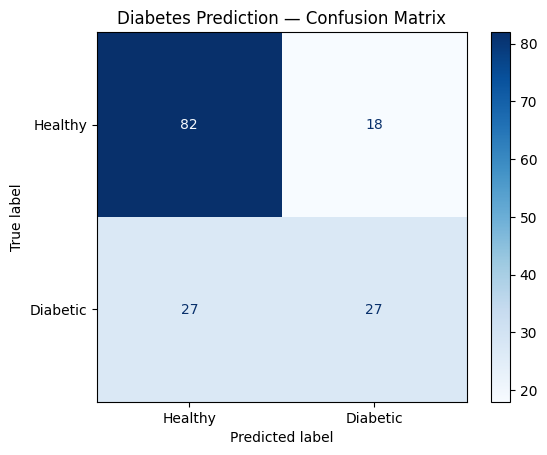

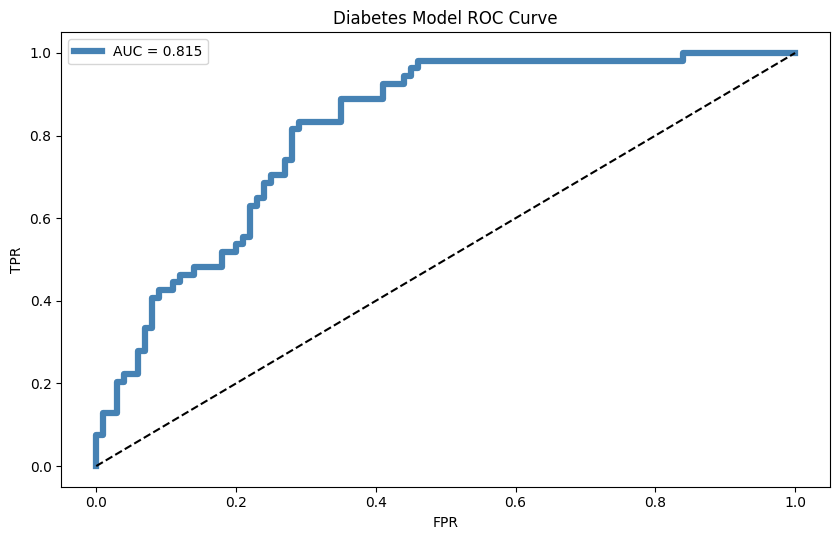

In [ ]:
# ■■ Evaluate ■■
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=['Healthy','Diabetic']))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','Diabetic']).plot(cmap='Blues')
plt.title('Diabetes Prediction — Confusion Matrix'); plt.show()
# ROC + AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(8.5, 5.5))
plt.plot(fpr, tpr, lw=4.5, color='steelblue', label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Diabetes Model ROC Curve'); plt.legend(); plt.tight_layout(); plt.show()
# Expected: Accuracy ~78%, AUC ~0.84

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Prediction : Diabetic
Probability : 70.73764% chance of having diabetes


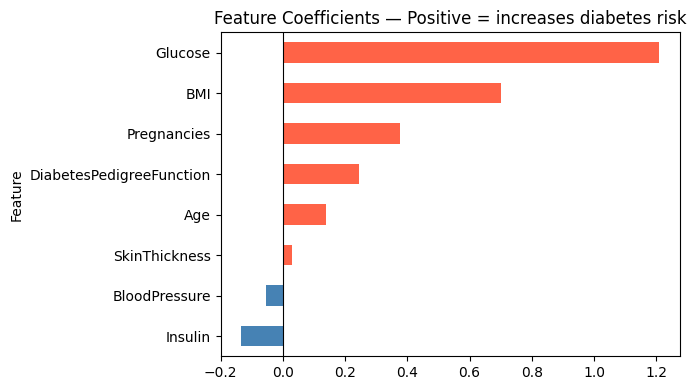

In [ ]:
# ■■ Predict New Patient + Coefficient Plot ■■
# Row: [Pregnancies, Glucose, BP, SkinThickness, Insulin, BMI, DPF, Age]
new_patient = np.array([[3, 123, 85, 25, 0, 42.6, 0.985, 60]])
new_scaled = scaler.transform(new_patient) # must use same scaler
pred = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)[0, 1]
print(f'Prediction : {'Diabetic' if pred==1 else 'Healthy'}')
print(f'Probability : {prob:.1%} chance of having diabetes')
# BONUS: Plot coefficients as a horizontal bar chart
import pandas as pd
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')
coef_df.plot(kind='barh', x='Feature', y='Coefficient',
color=['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']],
legend=False, figsize=(7, 4))
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Positive = increases diabetes risk')
plt.tight_layout(); plt.show()